Assignment 1 — Reconstructing the past: estimating solar radio flux F10.7 from sunspot records
Team: Vladislav Romenko, Igor Meleshin, Evgeniy Bobykin - Skoltech, 2026

1–2. Introduction and data

We observe two indicators of solar activity:

- Sunspot number — an index based on the observed number of sunspots and sunspot groups.
- Solar radio flux F10.7 — solar radio emission measured at a wavelength of 10.7 cm (2800 MHz), expressed in solar flux units (sfu).

The provided files contain monthly mean values. A monthly mean is one representative value for each month, calculated from observations inside that month.

The sunspot record extends much further into the past than the F10.7 record. The aim of the assignment is to study the relationship between these two indicators and use this relationship to reconstruct F10.7 for the earlier period.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read data and transfer it to the NumPy array
radio_data = np.loadtxt("data/Radio_flux_monthly_mean.txt")
sunspot_data = np.loadtxt("data/Sunspot_number_monthly_mean.txt")

In [3]:
# Check that value successfully imported
print("Radio flux:")
print(radio_data[:5])

print("\nSunspot number:")
print(sunspot_data[:5])

Radio flux:
[[1.951e+03 1.100e+01 1.050e+02]
 [1.951e+03 1.200e+01 1.039e+02]
 [1.952e+03 1.000e+00 9.550e+01]
 [1.952e+03 2.000e+00 8.710e+01]
 [1.952e+03 3.000e+00 7.830e+01]]

Sunspot number:
[[1.749e+03 1.000e+00 9.670e+01]
 [1.749e+03 2.000e+00 1.043e+02]
 [1.749e+03 3.000e+00 1.167e+02]
 [1.749e+03 4.000e+00 9.280e+01]
 [1.749e+03 5.000e+00 1.417e+02]]


In [4]:
# Display numbers in regular decimal format
np.set_printoptions(suppress=True)

# Check that the data were imported correctly
print("Radio flux:")
print(radio_data[:5])

print("\nSunspot number:")
print(sunspot_data[:5])

Radio flux:
[[1951.    11.   105. ]
 [1951.    12.   103.9]
 [1952.     1.    95.5]
 [1952.     2.    87.1]
 [1952.     3.    78.3]]

Sunspot number:
[[1749.     1.    96.7]
 [1749.     2.   104.3]
 [1749.     3.   116.7]
 [1749.     4.    92.8]
 [1749.     5.   141.7]]


In [5]:
# Extract year, month, and measurement values from the radio flux dataset 
# and sunspot dataset for use it in a plot
radio_year = radio_data[:, 0]
radio_month = radio_data[:, 1]
radio_flux = radio_data[:, 2]

sunspot_year = sunspot_data[:, 0]
sunspot_month = sunspot_data[:, 1]
sunspot_number = sunspot_data[:, 2]

# Show the result of splitting the original tables into separate arrays
print("Radio flux data:")
print("Years:", radio_year[:5])
print("Months:", radio_month[:5])
print("F10.7:", radio_flux[:5])
print()
print("Sunspot data:")
print("Years:", sunspot_year[:5])
print("Months:", sunspot_month[:5])
print("Sunspot number:", sunspot_number[:5])

Radio flux data:
Years: [1951. 1951. 1952. 1952. 1952.]
Months: [11. 12.  1.  2.  3.]
F10.7: [105.  103.9  95.5  87.1  78.3]

Sunspot data:
Years: [1749. 1749. 1749. 1749. 1749.]
Months: [1. 2. 3. 4. 5.]
Sunspot number: [ 96.7 104.3 116.7  92.8 141.7]


In [6]:
# Convert year and month into a continuous time axis in decimal years
radio_time = radio_year + (radio_month - 1) / 12
sunspot_time = sunspot_year + (sunspot_month - 1) / 12

print("Radio time:", radio_time[:5])
print("Sunspot time:", sunspot_time[:5])

Radio time: [1951.83333333 1951.91666667 1952.         1952.08333333 1952.16666667]
Sunspot time: [1749.         1749.08333333 1749.16666667 1749.25       1749.33333333]


3. Monthly mean sunspot number and F10.7

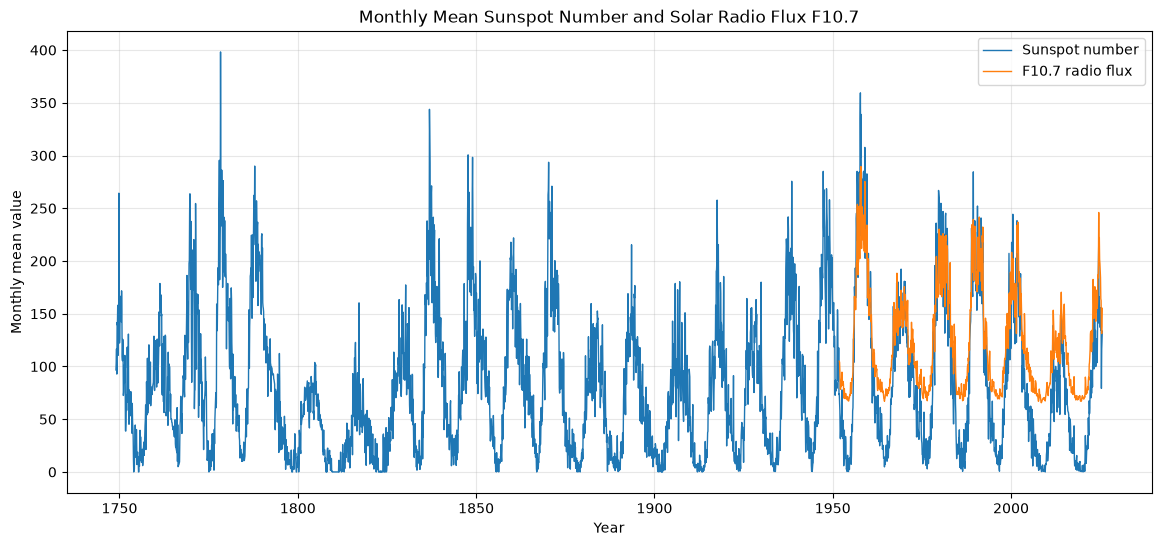

In [7]:
# Create a figure (we have a long time range, so we need a wide plot (14))
plt.figure(figsize=(14, 6))

# Plot the monthly mean sunspot number versus time
plt.plot(
    sunspot_time, # axis x
    sunspot_number, # axis y 
    label="Sunspot number", # name of the line
    linewidth=1 # line thickness
)

# Plot the monthly mean F10.7 radio flux versus time
plt.plot(
    radio_time,
    radio_flux,
    label="F10.7 radio flux",
    linewidth=1
)

# Imagine the data
plt.title("Monthly Mean Sunspot Number and Solar Radio Flux F10.7")
plt.xlabel("Year")
plt.ylabel("Monthly mean value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The x-axis represents time in years. The y-axis represents the monthly mean value of the solar activity indicator: sunspot number and F10.7 radio flux. 

Observation

The sunspot number and F10.7 radio flux show clear cyclic behavior over time. During the overlapping period, the two curves show similar behavior. So we can use regression model to predict F10.7 using sunspot numbers.

Similarities and differences

Similarities:
- Both indicators show clear cyclic behavior over time.
- During the period where both datasets are available, their increases and decreases generally occur at similar times. 

Differences:
- The two indicators represent different physical quantities: the sunspot number is based on observed sunspots and sunspot groups, while F10.7 measures solar radio emission at 10.7 cm.


4. 13-month running mean

The monthly data still contain many short-term fluctuations. To see the general solar cycle more clearly, we smooth the data using a 13-month running mean.

For each month, we use 13 monthly values:

- 6 months before,
- the current month,
- 6 months after.

The two values at the edges are given half weight, while the 11 values in the middle are given full weight.

The purpose of this averaging is to reduce fast month-to-month variations and make the long-term solar cycle easier to see.

The running mean used in the assignment is:

$$
\bar{R}_i =
\frac{1}{24}R_{i-6}
+
\frac{1}{12}(R_{i-5}+R_{i-4}+\cdots+R_{i+5})
+
\frac{1}{24}R_{i+6}
$$

In [8]:
def running_mean_13(data):
    smoothed = np.zeros(len(data)) # making array with 0 with the same length as the input data

    for i in range (len(data)): # through every month in the dataset and calculate its smoothed value
        if i < 6: # first 6 months (if there no enough previous months)
            values = data[:i + 7] # taking all available values around current month
            smoothed[i] = np.sum(values) / len(values) # calculate mean

        elif i >= len(data) - 6: # the same but for last 6 months
            values = data[i - 6:]
            smoothed[i] = np.sum(values) / len(values)

        else: # all other months 
            left = data[i - 6] / 24 # value 6 months before the current month with coef. 1/24 (half of normal 1/12)
            middle = np.sum(data[i - 5:i + 6]) / 12 # taking 11 months from 5 months before to 5 months after current month.
            right = data[i + 6] / 24 # value 6 months after the current month

            smoothed[i] = left + middle + right # sum of the three parts

    return smoothed

In [9]:
# Apply the 13-month running mean to both datasets
sunspot_smoothed = running_mean_13(sunspot_number)
radio_smoothed = running_mean_13(radio_flux)

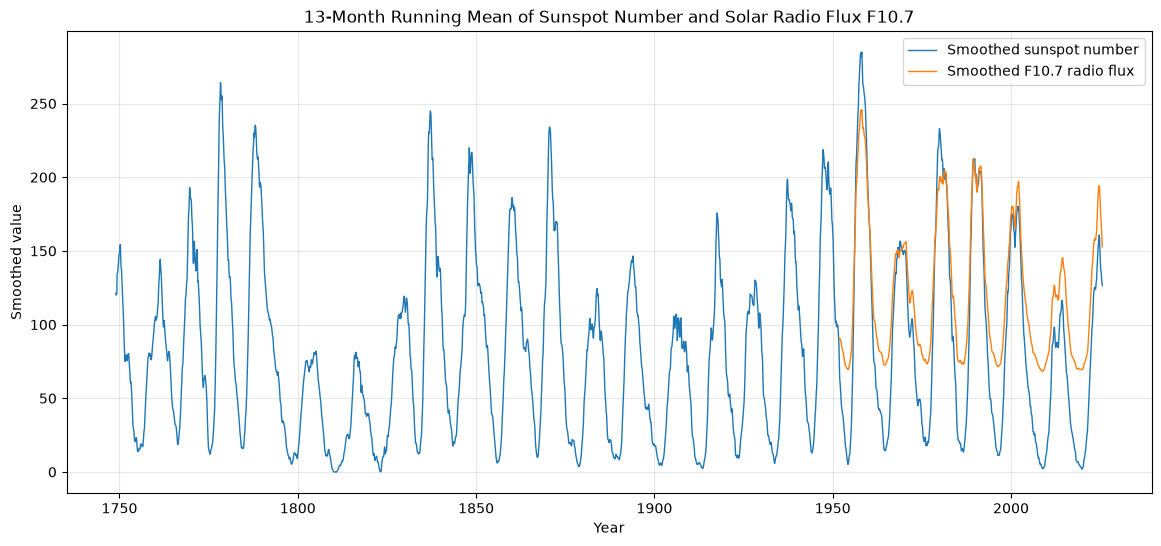

In [10]:
# Create a figure (we have a long time range, so we need a wide plot (14))
plt.figure(figsize=(14, 6))

# Plot the monthly mean sunspot number versus time
plt.plot(
    sunspot_time, # axis x
    sunspot_smoothed, # axis y 
    label="Smoothed sunspot number", # name of the line
    linewidth=1 # line thickness
)

# Plot the monthly mean F10.7 radio flux versus time
plt.plot(
    radio_time,
    radio_smoothed,
    label="Smoothed F10.7 radio flux",
    linewidth=1
)

# Add the plot title and axis labels
plt.title("13-Month Running Mean of Sunspot Number and Solar Radio Flux F10.7")
plt.xlabel("Year")
plt.ylabel("Smoothed value")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Explanation

The x-axis represents time in years. The y-axis represents the smoothed values of the two solar activity indicators.

The blue line represents the 13-month running mean of the sunspot number. The orange line represents the 13-month running mean of the F10.7 radio flux.

Each smoothed value is calculated using the neighboring monthly values around the current month. Therefore, short-term month-to-month fluctuations have less influence on the curves.

Observation

After applying the 13-month running mean, both curves become smoother compared with the original monthly mean data.

Short-term fluctuations are reduced, while the main cyclic behavior remains visible. The major increases, decreases, maxima, and minima are therefore easier to observe.

During the overlapping period, the smoothed sunspot number and F10.7 curves still show similar behavior. When the smoothed sunspot number increases, the smoothed F10.7 generally increases as well.

5. Relationship between sunspot number and F10.7

We need to check whether there is a direct relationship between the smoothed sunspot number and the smoothed F10.7 radio flux. The two datasets are available for different time periods, so first we need to identify the interval where both measurements exist at the same time.

After selecting this common period, we compare the two smoothed indicators using a scatter plot.

In [11]:
# Find the time interval where both datasets are available
overlap_start = max(sunspot_time[0], radio_time[0]) # taking max from both starts of the period
overlap_end = min(sunspot_time[-1], radio_time[-1]) # taking min from both ends of the period 

print("Common period:")
print("Start:", overlap_start)
print("End:", overlap_end)

Common period:
Start: 1951.8333333333333
End: 2025.5833333333333


Common period

The common observation period starts at approximately 1951.83 (november 1951) and ends at approximately 2025.58 (august 2025).

In [12]:
# Create a filter for the common period in the sunspot dataset
sunspot_in_common_period = (
    (sunspot_time >= overlap_start) # dates which is after common period
    & (sunspot_time <= overlap_end) # dates which is before common period
)

# Select only the smoothed sunspot values from the common period
sunspot_overlap = sunspot_smoothed[sunspot_in_common_period]

In [13]:
# Create a filter for the common period in the F10.7 dataset
radio_in_common_period = (
    (radio_time >= overlap_start) # dates which is after common period
    & (radio_time <= overlap_end) # dates which is before common period
)

# Select only the smoothed F10.7 values from the common period
radio_overlap = radio_smoothed[radio_in_common_period]

In [14]:
# Select the time values from the common period
sunspot_time_overlap = sunspot_time[sunspot_in_common_period]
radio_time_overlap = radio_time[radio_in_common_period]

# Check that both datasets contain the same number of observations
print("Number of sunspot observations:", len(sunspot_overlap))
print("Number of F10.7 observations:", len(radio_overlap))

# Show the first five time values and corresponding smoothed measurements
print("\nFirst sunspot times:", sunspot_time_overlap[:5])
print("First F10.7 times:", radio_time_overlap[:5])

print("\nFirst sunspot values:", sunspot_overlap[:5])
print("First F10.7 values:", radio_overlap[:5])
print()
# Check that the time points are the same in both datasets
same_times = np.allclose(sunspot_time_overlap, radio_time_overlap)
print("Do all time points match:", same_times)

Number of sunspot observations: 886
Number of F10.7 observations: 886

First sunspot times: [1951.83333333 1951.91666667 1952.         1952.08333333 1952.16666667]
First F10.7 times: [1951.83333333 1951.91666667 1952.         1952.08333333 1952.16666667]

First sunspot values: [75.2875     66.51666667 61.45416667 59.79583333 56.2125    ]
First F10.7 values: [90.68571429 89.925      89.78888889 90.27       89.66363636]

Do all time points match: True


Data check

The common observation period contains 886 monthly values for both the sunspot number and F10.7 datasets.

The first time values are the same in both datasets, starting from approximately November 1951. The corresponding smoothed sunspot and F10.7 values therefore refer to the same months.

For example, for the first common month, the smoothed sunspot number is approximately 75.29 and the smoothed F10.7 value is approximately 90.69.

The final check returns True, confirming that all time points match between the two datasets. This means that the two smoothed datasets are correctly aligned and can be compared directly in the scatter plot.

In [15]:
# Select raw sunspot values from the common period
sunspot_raw_overlap = sunspot_number[sunspot_in_common_period]

# Select raw F10.7 values from the common period
radio_raw_overlap = radio_flux[radio_in_common_period]

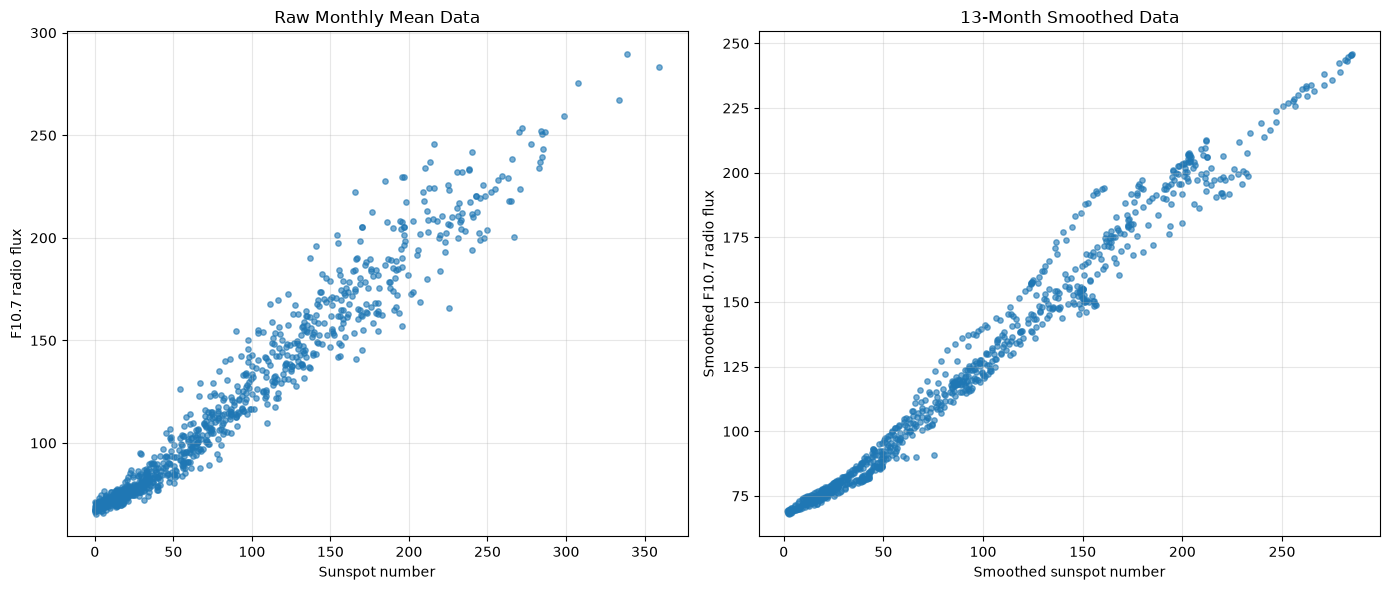

In [16]:
# Create two scatter plots side by side:
# the left plot will show the original monthly mean data,
# and the right plot will show the same data after 13-month smoothing.
fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# left plot: original monthly mean values
# Each point represents one month from the common observation period.
axes[0].scatter(
    sunspot_raw_overlap,   # x-axis: original monthly mean sunspot number
    radio_raw_overlap,     # y-axis: original monthly mean F10.7 value
    s=15,
    alpha=0.6
)
axes[0].set_title("Raw Monthly Mean Data")
axes[0].set_xlabel("Sunspot number")
axes[0].set_ylabel("F10.7 radio flux")
axes[0].grid(True, alpha=0.3)


# right plot: 13-month smoothed values
# Each point again represents one month from the same common period,
# but now both sunspot number and F10.7 have been smoothed.
axes[1].scatter(
    sunspot_overlap,       # x-axis: 13-month smoothed sunspot number
    radio_overlap,         # y-axis: 13-month smoothed F10.7 value
    s=15,
    alpha=0.6
)
axes[1].set_title("13-Month Smoothed Data")
axes[1].set_xlabel("Smoothed sunspot number")
axes[1].set_ylabel("Smoothed F10.7 radio flux")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Comparison of raw and smoothed scatter plots

The left plot shows the original monthly mean data.

- The x-axis shows the sunspot number.
- The y-axis shows the F10.7 radio flux.
- Each point represents one month.
- For each month, the sunspot number is placed on the x-axis and the F10.7 value from the same month is placed on the y-axis.

The points do not need to have the same x and y values. The important thing is whether larger sunspot numbers are usually connected with larger F10.7 values.
In the raw-data plot, the points are more spread out. This means that for similar sunspot numbers, F10.7 can be quite different from month to month.

The right plot shows the same relationship after applying the 13-month running mean.
After smoothing, short-term monthly fluctuations are reduced. Because of this, the points are closer to the main trend and the relationship becomes easier to see.
In both plots, the points generally move from the lower-left part to the upper-right part. This means that when the sunspot number increases, F10.7 usually also increases.
The smoothed plot shows this relationship more clearly because there is less short-term variation.

6. Polynomial regression model

In the previous step, we saw that the sunspot number and F10.7 are related. 
Now we use the smoothed sunspot number as the input and the smoothed F10.7 radio flux as the output.
Then we use the Least Squares Method to calculate the coefficients of the regression model.
The third-order model used in the assignment is:

$$
F_i = \beta_0 + \beta_1R_i + \beta_2R_i^2 + \beta_3R_i^3 + \varepsilon_i
$$

7. Regression variables

Input and output data

R_values contains the smoothed sunspot numbers.
F contains the smoothed F10.7 values for the same months.
The sunspot number is used as the input of the model, while F10.7 is the value that we want to describe.

In [17]:
# Use the smoothed values from the common period

# Sunspot number
R_values = sunspot_overlap

# F10.7 radio flux
F = radio_overlap

# Check the first values
print("First R values:", R_values[:5])
print("First F values:", F[:5])

First R values: [75.2875     66.51666667 61.45416667 59.79583333 56.2125    ]
First F values: [90.68571429 89.925      89.78888889 90.27       89.66363636]


Polynomial terms

For each sunspot value, we calculate its square and cube.

These additional values allow the regression model to describe a curved relationship instead of only a straight line.

In [18]:
# Calculate R squared and R cubed
R_squared = R_values ** 2
R_cubed = R_values ** 3

print("First R values:", R_values[:5])
print("First R^2 values:", R_squared[:5])
print("First R^3 values:", R_cubed[:5])

First R values: [75.2875     66.51666667 61.45416667 59.79583333 56.2125    ]
First R^2 values: [5668.20765625 4424.46694444 3776.61460069 3575.54168403 3159.84515625]
First R^3 values: [426745.18391992 294300.7929213  232088.70310684 213802.49461451
 177622.7958457 ]


Column of ones

A column of ones is created for the constant part of the regression model (bias).
It has the same number of elements as the sunspot dataset.

In [19]:
# Create a column of ones

ones = np.ones(len(R_values))

print("First values:", ones[:5])
print("Number of values:", len(ones))

First values: [1. 1. 1. 1. 1.]
Number of values: 886


Regression matrix

The separate arrays are combined into one matrix.

Each row represents one monthly observation.

The four columns contain:

1. the constant value 1,
2. the sunspot number,
3. the squared sunspot number,
4. the cubed sunspot number.

In [20]:
# Combine 1, R, R^2 and R^3 into one matrix

R_matrix = np.column_stack((
    ones,
    R_values,
    R_squared,
    R_cubed
))

print("First 5 rows of the regression matrix:")
print(R_matrix[:5])

First 5 rows of the regression matrix:
[[     1.             75.2875       5668.20765625 426745.18391992]
 [     1.             66.51666667   4424.46694444 294300.7929213 ]
 [     1.             61.45416667   3776.61460069 232088.70310684]
 [     1.             59.79583333   3575.54168403 213802.49461451]
 [     1.             56.2125       3159.84515625 177622.7958457 ]]


8. Least Squares estimation

The regression coefficients are calculated with the Least Squares Method:

$$
\hat{\beta} = (R^T R)^{-1}R^T F
$$

First part

The transposed matrix is multiplied by the original regression matrix.

This is one of the parts needed for the Least Squares calculation.

In [21]:
# Transpose the regression matrix
R_transpose = R_matrix.T
# Calculate the first part
first_part = R_transpose @ R_matrix
print("R^T * R:")
print(first_part)

# Calculate the inverse matrix
inverse_part = np.linalg.inv(first_part)

# Multiply the transposed matrix by F10.7 values
second_part = R_transpose @ F
print("R^T * F:")
print(second_part)

R^T * R:
[[8.86000000e+02 8.04301843e+04 1.17309154e+07 2.08334809e+09]
 [8.04301843e+04 1.17309154e+07 2.08334809e+09 4.12275287e+11]
 [1.17309154e+07 2.08334809e+09 4.12275287e+11 8.76736711e+13]
 [2.08334809e+09 4.12275287e+11 8.76736711e+13 1.96544729e+16]]
R^T * F:
[1.08093630e+05 1.27242998e+07 2.09968728e+09 3.99810272e+11]


In [22]:
# Calculate the regression coefficients
beta = inverse_part @ second_part

print("Regression coefficients:")
print("beta_0 =", beta[0])
print("beta_1 =", beta[1])
print("beta_2 =", beta[2])
print("beta_3 =", beta[3])

Regression coefficients:
beta_0 = 65.76267641765662
beta_1 = 0.4674051045466854
beta_2 = 0.001970556638096088
beta_3 = -5.2233291792328634e-06


Result of the regression step

In this step, we used the smoothed sunspot number as the input variable and the smoothed F10.7 radio flux as the output variable.
To describe the curved relationship between the two indicators, we used the sunspot number together with its squared and cubed values.
All monthly observations were combined into a regression matrix. Then the Least Squares Method was used to calculate the four regression coefficients.
The calculated coefficients are:

- beta_0 = 65.7627
- beta_1 = 0.4674
- beta_2 = 0.00197
- beta_3 = -5.22 × 10^-6

These coefficients define the regression model that connects the sunspot number with F10.7.
The model can now be used to estimate F10.7 for any given sunspot number.


9. Reconstruction of F10.7 on the measured period

In the previous step, we calculated the regression coefficients. Now we use these coefficients together with the smoothed sunspot numbers to calculate reconstructed F10.7 values. For each monthly sunspot value, the regression model gives one estimated F10.7 value.
At this stage, we first reconstruct F10.7 for the common observation period, where the real F10.7 measurements are also available.
This allows us to compare the reconstructed values with the measured values and check how well the model works.

Reconstruction result

The regression model calculates one reconstructed F10.7 value for every smoothed sunspot value.

The reconstructed values can now be compared with the measured F10.7 values from the same months.

In [23]:
# Calculate reconstructed F10.7 values
F_reconstructed = (
    beta[0]
    + beta[1] * R_values
    + beta[2] * R_squared
    + beta[3] * R_cubed
)

# Show the first five measured and reconstructed values
print("Measured F10.7:", F[:5])
print("Reconstructed F10.7:", F_reconstructed[:5])

Measured F10.7: [90.68571429 89.925      89.78888889 90.27       89.66363636]
Reconstructed F10.7: [109.89293188 104.03433874 100.71642489  99.64060074  97.33555737]


Comparison

The measured curve shows the real smoothed F10.7 observations.
The reconstructed curve shows the F10.7 values calculated by the regression model using only the smoothed sunspot number.
If the two curves are close to each other, the regression model describes the relationship between sunspot number and F10.7 well.
The remaining differences between the curves represent the reconstruction error.

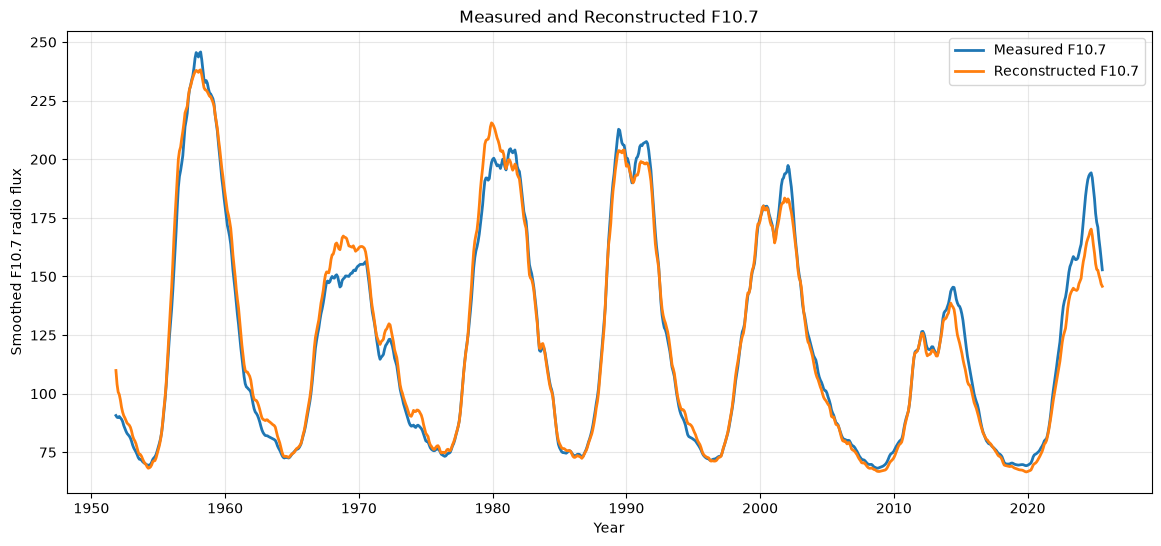

In [24]:
# Compare measured and reconstructed F10.7 values over time
plt.figure(figsize=(14, 6))

# Measured smoothed F10.7
plt.plot(
    radio_time_overlap,
    F,
    label="Measured F10.7",
    linewidth=2
)

# F10.7 reconstructed by the regression model
plt.plot(
    radio_time_overlap,
    F_reconstructed,
    label="Reconstructed F10.7",
    linewidth=2
)

plt.title("Measured and Reconstructed F10.7")
plt.xlabel("Year")
plt.ylabel("Smoothed F10.7 radio flux")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Observation

The reconstructed F10.7 curve follows the measured F10.7 curve quite closely. The model reproduces the main increases, decreases, peaks, and minima of the measured radio flux. The curves are not identical, so the model still has some error. However, the general behavior of F10.7 is reconstructed well from the sunspot number. This means that the regression model can be used to estimate F10.7 from sunspot data.

10. Root-mean-square error (RMSE)

The measured and reconstructed F10.7 curves are close, but they are not identical. To measure the reconstruction error numerically, we calculate the RMSE.
For each month, we calculate the difference between the measured F10.7 value and the reconstructed value. Then we square these differences, add them together, divide by the number of observations minus one, and take the square root.
A smaller RMSE means that the reconstructed values are closer to the measured values.

The error is calculated using:

$$
\sigma =
\sqrt{
\frac{1}{N-1}
\sum_{i=1}^{N}(f_i-\hat{f}_i)^2
}
$$

Monthly errors

The error for each month is calculated as the difference between the measured and reconstructed F10.7 values.
A positive error means that the model underestimated F10.7, while a negative error means that the model overestimated it.

In [25]:
# Calculate the difference between measured and reconstructed F10.7 values

errors = F - F_reconstructed

# Show the first five errors
print("First errors:", errors[:5])

First errors: [-19.20721759 -14.10933874 -10.927536    -9.37060074  -7.67192101]


RMSE result

The RMSE gives one numerical value that summarizes the difference between the measured and reconstructed F10.7 values.

A smaller RMSE means that the regression model reproduces the measured F10.7 values more accurately.

This value will also be used later to define the uncertainty range for the historical F10.7 reconstruction.

In [26]:
# calculate RMSE
squared_errors = errors ** 2
sum_squared_errors = np.sum(squared_errors)

print("Sum of squared errors:", sum_squared_errors)

# Number of observations
N = len(F)

# Calculate RMSE using the equation from the assignment
rmse = np.sqrt(
    sum_squared_errors / (N - 1)
)

print("Number of observations:", N)
print("RMSE:", rmse)

Sum of squared errors: 34960.01882662458
Number of observations: 886
RMSE: 6.285128966996555


RMSE result

The RMSE of the reconstructed F10.7 is approximately 6.29.
This means that the reconstructed F10.7 values typically differ from the measured values by about 6.3 F10.7 units.

Compared with the overall range of F10.7 values in the dataset, this error is relatively small. This confirms that the regression model reproduces the measured F10.7 values reasonably well.

The RMSE will be used in the next step to estimate the uncertainty of the historical F10.7 reconstruction.

11. Historical reconstruction of F10.7

F10.7 measurements are available only from the later part of the sunspot record. However, sunspot observations are available for a much longer historical period. Since we already found a relationship between the sunspot number and F10.7, we can now use the regression model to estimate F10.7 for the earlier period where only sunspot data are available.

We also add an uncertainty range of ±3 RMSE around the reconstructed values.

Historical sunspot data

Only the sunspot observations before the beginning of the common observation period are selected.
For this historical period, real F10.7 measurements are not available, so these sunspot values will be used as input for the regression model.

In [27]:
# Select the historical period before F10.7 measurements started
historical_period = sunspot_time < overlap_start

historical_time = sunspot_time[historical_period]
historical_R = sunspot_smoothed[historical_period]

print("First historical time:", historical_time[0])
print("Last historical time:", historical_time[-1])
print("Number of historical observations:", len(historical_R))

# Calculate squared and cubed historical sunspot values
historical_R_squared = historical_R ** 2
historical_R_cubed = historical_R ** 3

print("First R values:", historical_R[:5])
print("First R^2 values:", historical_R_squared[:5])
print("First R^3 values:", historical_R_cubed[:5])

# Reconstruct historical F10.7 values using the regression model
historical_F_reconstructed = (
    beta[0]
    + beta[1] * historical_R
    + beta[2] * historical_R_squared
    + beta[3] * historical_R_cubed
)

print("First reconstructed F10.7 values:")
print(historical_F_reconstructed[:5])

# Calculate the uncertainty range
uncertainty = 3 * rmse

print("RMSE:", rmse)
print("3 × RMSE:", uncertainty)

First historical time: 1749.0
Last historical time: 1951.75
Number of historical observations: 2434
First R values: [121.34285714 119.9875     120.71111111 121.22       134.22727273]
First R^2 values: [14724.08897959 14397.00015625 14571.17234568 14694.2884
 18016.9607438 ]
First R^3 values: [1786663.02560933 1727460.05624805 1758902.40403841 1781241.639848
 2418367.50347483]
First reconstructed F10.7 values:
[142.16126941 141.19245811 141.70966007 142.07343931 151.3727009 ]
RMSE: 6.285128966996555
3 × RMSE: 18.855386900989664


Uncertainty range

An uncertainty range of ±3 RMSE is added to the reconstructed F10.7 values.

This range shows that the reconstructed values are estimates and are not expected to be exact.

In [28]:
# Calculate lower and upper uncertainty bounds

lower_bound = historical_F_reconstructed - uncertainty
upper_bound = historical_F_reconstructed + uncertainty

print("First reconstructed value:", historical_F_reconstructed[0])
print("First lower bound:", lower_bound[0])
print("First upper bound:", upper_bound[0])

First reconstructed value: 142.16126941003776
First lower bound: 123.3058825090481
First upper bound: 161.01665631102742


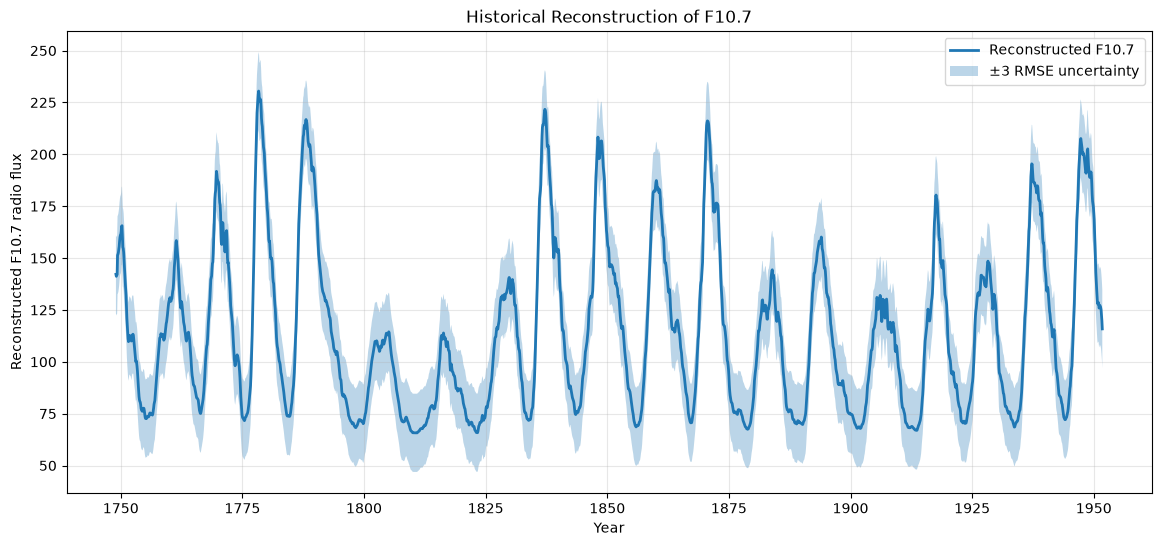

In [29]:
# Plot the historical F10.7 reconstruction

plt.figure(figsize=(14, 6))

# Reconstructed historical F10.7
plt.plot(
    historical_time,
    historical_F_reconstructed,
    label="Reconstructed F10.7",
    linewidth=2
)

# Uncertainty range
plt.fill_between(
    historical_time,
    lower_bound,
    upper_bound,
    alpha=0.3,
    label="±3 RMSE uncertainty"
)

plt.title("Historical Reconstruction of F10.7")
plt.xlabel("Year")
plt.ylabel("Reconstructed F10.7 radio flux")

plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Result

The regression model was applied to the historical smoothed sunspot data to reconstruct F10.7 for the period before direct F10.7 measurements became available.

The blue curve shows the estimated historical F10.7 values. Its cyclic behavior follows the long-term changes in the historical sunspot record.

The shaded area represents the uncertainty range of ±3 RMSE around the reconstructed values.

Therefore, the reconstructed F10.7 values should be interpreted as estimates rather than direct measurements.

This approach extends the F10.7 record backward in time using the much longer historical sunspot record.

Extended F10.7 record

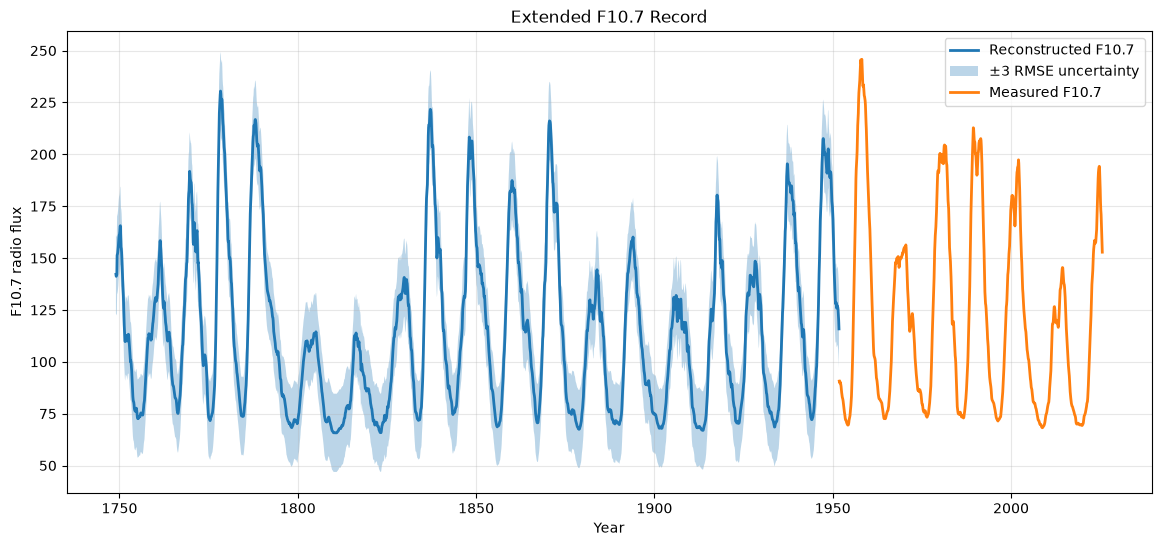

In [30]:
# Show the reconstructed historical record together with measured F10.7

plt.figure(figsize=(14, 6))

plt.plot(
    historical_time,
    historical_F_reconstructed,
    label="Reconstructed F10.7",
    linewidth=2
)

plt.fill_between(
    historical_time,
    lower_bound,
    upper_bound,
    alpha=0.3,
    label="±3 RMSE uncertainty"
)

plt.plot(
    radio_time_overlap,
    F,
    label="Measured F10.7",
    linewidth=2
)

plt.title("Extended F10.7 Record")
plt.xlabel("Year")
plt.ylabel("F10.7 radio flux")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The combined plot shows the reconstructed historical period and the directly measured F10.7 record on one time axis.

Conclusions
The assignment covered the main steps of experimental data processing: preparing the data, smoothing, building a model, estimating the error, and reconstructing missing values.
The 13-month running mean reduced short-term fluctuations and made the relationship between sunspot number and F10.7 easier to see.
Using the common observation period, we built a third-order regression model with the Least Squares Method.
The reconstructed F10.7 followed the measured data reasonably well. The RMSE was about 6.29.
The model was then used to reconstruct F10.7 for the earlier period, when only sunspot data were available. The uncertainty range was set to ±3 RMSE, or about ±18.86.
Overall, the assignment showed how one measured quantity can be used to estimate another, while still taking the model error and uncertainty into account.

Learning Log

In this assignment, we worked with data preprocessing, smoothing, regression, error estimation, and historical reconstruction of F10.7.
The main difficulties were understanding how to correctly align the two datasets, how the 13-month smoothing works, and how to interpret the regression and RMSE results.
We solved these problems by checking the common time period, comparing raw and smoothed data, going through the regression calculation step by step, and comparing reconstructed F10.7 with the measured values.
As a result, we learned how to use experimental data to build a model, estimate its error, and reconstruct values for a period where direct measurements are not available.

Team Contribution

The assignment was completed by a team of three students.
The work was divided between data preparation and visualization, implementation of the main calculations, and analysis of the obtained results.
Each team member worked on a separate part of the assignment, while the main intermediate results were discussed and checked together.
The final reconstruction, error estimation, conclusions, and report were reviewed jointly before submission.